# NextQA Frame Selection Comparison

This notebook compares two frame-selection methods:
- `outputs/nextqa/nextqa_keyframes`
- `outputs/nextqa/nextqa_temporal_chain_keyframes`


In [2]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

BASE_DIR = Path('outputs/nextqa')
DIR_A = BASE_DIR / 'nextqa_keyframes'
DIR_B = BASE_DIR / 'nextqa_temporal_chain_keyframes'

assert DIR_A.exists(), f'Missing folder: {DIR_A}'
assert DIR_B.exists(), f'Missing folder: {DIR_B}'

print('Method A:', DIR_A)
print('Method B:', DIR_B)


Method A: outputs/nextqa/nextqa_keyframes
Method B: outputs/nextqa/nextqa_temporal_chain_keyframes


In [2]:
def load_method(folder: Path) -> dict:
    data = {}
    for fp in sorted(folder.glob('*.json')):
        obj = json.loads(fp.read_text())
        if len(obj) != 1:
            continue
        qid, pairs = next(iter(obj.items()))
        frame_indices = [int(x[0]) for x in pairs]
        ranks = [int(x[1]) for x in pairs]
        data[str(qid)] = {
            'frames': frame_indices,
            'ranks': ranks,
            'k': len(frame_indices),
        }
    return data

A = load_method(DIR_A)
B = load_method(DIR_B)

ids_a = set(A)
ids_b = set(B)
common_ids = sorted(ids_a & ids_b)
only_a = sorted(ids_a - ids_b)
only_b = sorted(ids_b - ids_a)

print(f'Method A samples: {len(ids_a):,}')
print(f'Method B samples: {len(ids_b):,}')
print(f'Common samples:   {len(common_ids):,}')
print(f'Only A samples:   {len(only_a):,}')
print(f'Only B samples:   {len(only_b):,}')


Method A samples: 4,996
Method B samples: 1,385
Common samples:   1,385
Only A samples:   3,611
Only B samples:   0


In [3]:
def metrics_for_id(qid: str, topk: int = 12) -> dict:
    a = A[qid]['frames'][:topk]
    b = B[qid]['frames'][:topk]

    set_a, set_b = set(a), set(b)
    inter = len(set_a & set_b)
    union = len(set_a | set_b)

    pos_a = {f: i for i, f in enumerate(a)}
    pos_b = {f: i for i, f in enumerate(b)}
    shared = sorted(set_a & set_b)

    rank_diff = np.mean([abs(pos_a[f] - pos_b[f]) for f in shared]) if shared else np.nan

    return {
        'qid': qid,
        'k_a': len(a),
        'k_b': len(b),
        'overlap_count': inter,
        'jaccard': inter / union if union else np.nan,
        'overlap_ratio_a': inter / len(a) if len(a) else np.nan,
        'overlap_ratio_b': inter / len(b) if len(b) else np.nan,
        'mean_abs_rank_diff_shared': rank_diff,
    }

df = pd.DataFrame(metrics_for_id(qid, topk=12) for qid in common_ids)
df.head()


,qid,k_a,k_b,overlap_count,jaccard,overlap_ratio_a,overlap_ratio_b,mean_abs_rank_diff_shared
0,100017877251,12,12,0,0.000000,0.000000,0.000000,NaN
1,100017877254,12,12,0,0.000000,0.000000,0.000000,NaN
2,100017877256,12,12,0,0.000000,0.000000,0.000000,NaN
3,100306099341,12,12,1,0.043478,0.083333,0.083333,3.0
4,100306099342,12,12,1,0.043478,0.083333,0.083333,1.0


In [4]:
summary = df[['overlap_count', 'jaccard', 'overlap_ratio_a', 'overlap_ratio_b', 'mean_abs_rank_diff_shared']].describe().T
summary


,count,mean,std,min,25%,50%,75%,max
overlap_count,1385.0,0.992780,1.049335,0.0,0.0,1.000000,2.000000,5.000000
jaccard,1385.0,0.045434,0.050182,0.0,0.0,0.043478,0.090909,0.263158
overlap_ratio_a,1385.0,0.082732,0.087445,0.0,0.0,0.083333,0.166667,0.416667
overlap_ratio_b,1385.0,0.082732,0.087445,0.0,0.0,0.083333,0.166667,0.416667
mean_abs_rank_diff_shared,830.0,4.075422,2.455221,0.0,2.0,4.000000,6.000000,11.000000


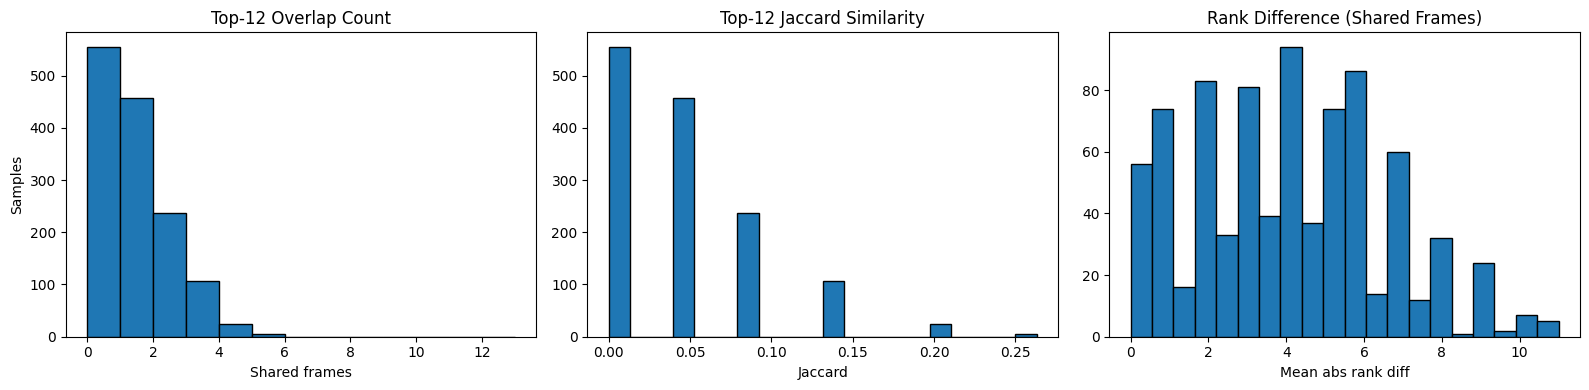

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(df['overlap_count'].dropna(), bins=range(0, 14), edgecolor='black')
axes[0].set_title('Top-12 Overlap Count')
axes[0].set_xlabel('Shared frames')
axes[0].set_ylabel('Samples')

axes[1].hist(df['jaccard'].dropna(), bins=20, edgecolor='black')
axes[1].set_title('Top-12 Jaccard Similarity')
axes[1].set_xlabel('Jaccard')

axes[2].hist(df['mean_abs_rank_diff_shared'].dropna(), bins=20, edgecolor='black')
axes[2].set_title('Rank Difference (Shared Frames)')
axes[2].set_xlabel('Mean abs rank diff')

plt.tight_layout()
plt.show()


In [6]:
# Inspect strongest / weakest agreement examples
best = df.sort_values(['jaccard', 'overlap_count'], ascending=False).head(10)
worst = df.sort_values(['jaccard', 'overlap_count'], ascending=True).head(10)

print('Best agreement samples:')
display(best[['qid', 'overlap_count', 'jaccard', 'mean_abs_rank_diff_shared']])
print('\nWorst agreement samples:')
display(worst[['qid', 'overlap_count', 'jaccard', 'mean_abs_rank_diff_shared']])


Best agreement samples:


,qid,overlap_count,jaccard,mean_abs_rank_diff_shared
86,24011677407,5,0.263158,3.80
744,48969696170,5,0.263158,3.40
745,48969696179,5,0.263158,5.40
1189,76911729220,5,0.263158,3.00
1190,76911729221,5,0.263158,4.00
66,132960541832,4,0.200000,3.25
161,27162779607,4,0.200000,3.50
180,27823070490,4,0.200000,3.25
181,27823070491,4,0.200000,3.25
182,27823070492,4,0.200000,2.75



Worst agreement samples:


,qid,overlap_count,jaccard,mean_abs_rank_diff_shared
0,100017877251,0,0.0,NaN
1,100017877254,0,0.0,NaN
2,100017877256,0,0.0,NaN
18,103095422553,0,0.0,NaN
19,105975338854,0,0.0,NaN
20,105975338856,0,0.0,NaN
21,106070959366,0,0.0,NaN
22,107276961432,0,0.0,NaN
23,107276961433,0,0.0,NaN
24,107276961434,0,0.0,NaN


In [7]:
# Optional: inspect exact frame lists for a specific question ID
sample_qid = common_ids[0] if common_ids else None
print('sample_qid =', sample_qid)
if sample_qid is not None:
    print('Method A frames:', A[sample_qid]['frames'])
    print('Method B frames:', B[sample_qid]['frames'])


sample_qid = 100017877251
Method A frames: [649, 504, 826, 590, 408, 154, 777, 46, 336, 417, 721, 222]
Method B frames: [802, 724, 312, 921, 619, 474, 876, 402, 105, 14, 536, 207]


## Answer Difference Analysis

This section compares answer outputs from:
- `outputs/nextqa/nextqa_ktv_token_only_uniform_token_tokens1872.json`
- `outputs/nextqa/temporal_chain/20260521T050745Z_pid1009647/predictions.json`


In [4]:
import re

ANSWER_PATH_A = Path('outputs/nextqa/nextqa_ktv_token_only_uniform_token_tokens1872.json')
ANSWER_PATH_B = Path('outputs/nextqa/temporal_chain/20260521T050745Z_pid1009647/predictions.json')
ANSWER_LABEL_A = 'token_only'
ANSWER_LABEL_B = 'temporal_chain'


def load_prediction_records(path: Path) -> dict:
    text = path.read_text().strip()
    if not text:
        return {}

    try:
        payload = json.loads(text)
        if isinstance(payload, list):
            items = payload
        elif isinstance(payload, dict) and isinstance(payload.get('predictions'), list):
            items = payload['predictions']
        else:
            items = [payload]
    except json.JSONDecodeError:
        items = [json.loads(line) for line in text.splitlines() if line.strip()]

    return {
        str(item.get('question_id') or item.get('id')): item
        for item in items
        if item.get('question_id') is not None or item.get('id') is not None
    }


def normalize_answer_text(value: str | None) -> str | None:
    if value is None:
        return None
    value = re.sub(r'\s+', ' ', str(value).strip())
    value = value.rstrip(' .')
    return value.lower()


def extract_choice_letter(value: str | None) -> str | None:
    if not value:
        return None
    match = re.match(r'^\s*([A-E])\s*[\)\].:-]?', str(value), flags=re.I)
    return match.group(1).upper() if match else None


def canonicalize_prediction(pred: str | None, candidates: list[str]) -> dict:
    pred_raw = '' if pred is None else str(pred).strip()
    pred_letter = extract_choice_letter(pred_raw)
    pred_idx = None
    pred_text = pred_raw

    if pred_letter is not None:
        pred_idx = ord(pred_letter) - ord('A')
        if 0 <= pred_idx < len(candidates):
            pred_text = candidates[pred_idx]
    elif pred_raw:
        pred_text = re.sub(r'^\s*[A-E]\s*[\)\].:-]?\s*', '', pred_raw, flags=re.I)

    pred_norm = normalize_answer_text(pred_text)
    candidate_norms = [normalize_answer_text(candidate) for candidate in candidates]
    if pred_idx is None and pred_norm in candidate_norms:
        pred_idx = candidate_norms.index(pred_norm)

    return {
        'pred_raw': pred_raw,
        'pred_letter': pred_letter,
        'pred_idx': pred_idx,
        'pred_text': pred_text,
        'pred_norm': pred_norm,
    }


def resolve_gold(item: dict, candidates: list[str]) -> tuple[int | None, str | None]:
    gold_idx = item.get('answer_number')
    if gold_idx is not None:
        gold_idx = int(gold_idx)
    else:
        gold_norm = normalize_answer_text(item.get('answer'))
        candidate_norms = [normalize_answer_text(candidate) for candidate in candidates]
        if gold_norm in candidate_norms:
            gold_idx = candidate_norms.index(gold_norm)

    gold_text = candidates[gold_idx] if gold_idx is not None and 0 <= gold_idx < len(candidates) else item.get('answer')
    return gold_idx, gold_text


records_a = load_prediction_records(ANSWER_PATH_A)
records_b = load_prediction_records(ANSWER_PATH_B)
common_answer_ids = sorted(set(records_a) & set(records_b))

answer_rows = []
for qid in common_answer_ids:
    item_a = records_a[qid]
    item_b = records_b[qid]
    item_ref = item_a if item_a.get('candidates') else item_b

    candidates = item_ref.get('candidates') or []
    gold_idx, gold_text = resolve_gold(item_ref, candidates)
    parsed_a = canonicalize_prediction(item_a.get('pred'), candidates)
    parsed_b = canonicalize_prediction(item_b.get('pred'), candidates)

    correct_a = parsed_a['pred_idx'] == gold_idx if gold_idx is not None else None
    correct_b = parsed_b['pred_idx'] == gold_idx if gold_idx is not None else None

    answer_rows.append({
        'qid': qid,
        'question': item_ref.get('question'),
        'candidates': candidates,
        'gold_idx': gold_idx,
        'gold_text': gold_text,
        f'{ANSWER_LABEL_A}_pred_raw': parsed_a['pred_raw'],
        f'{ANSWER_LABEL_A}_pred_idx': parsed_a['pred_idx'],
        f'{ANSWER_LABEL_A}_pred_text': parsed_a['pred_text'],
        f'{ANSWER_LABEL_A}_correct': correct_a,
        f'{ANSWER_LABEL_B}_pred_raw': parsed_b['pred_raw'],
        f'{ANSWER_LABEL_B}_pred_idx': parsed_b['pred_idx'],
        f'{ANSWER_LABEL_B}_pred_text': parsed_b['pred_text'],
        f'{ANSWER_LABEL_B}_correct': correct_b,
        'same_choice': parsed_a['pred_idx'] == parsed_b['pred_idx'],
        'same_text': normalize_answer_text(parsed_a['pred_text']) == normalize_answer_text(parsed_b['pred_text']),
        'flipped_to_correct': (correct_a is False) and (correct_b is True),
        'flipped_to_wrong': (correct_a is True) and (correct_b is False),
    })

answers_df = pd.DataFrame(answer_rows)
print(f'Loaded {len(records_a):,} predictions from A and {len(records_b):,} from B')
print(f'Common question IDs: {len(common_answer_ids):,}')
answers_df.head()


Loaded 4,996 predictions from A and 4,996 from B
Common question IDs: 4,996


,qid,question,candidates,gold_idx,gold_text,token_only_pred_raw,token_only_pred_idx,token_only_pred_text,token_only_correct,temporal_chain_pred_raw,temporal_chain_pred_idx,temporal_chain_pred_text,temporal_chain_correct,same_choice,same_text,flipped_to_correct,flipped_to_wrong
0,100017877251,why did the woman hold the baby when the baby ...,"[go somewhere, support herself, talking to kid...",4,protect from falling,E) protect from falling. The baby is on the ed...,4,protect from falling,True,E) protect from falling,4,protect from falling,True,True,True,False,False
1,100017877252,why is there a fan on the sofa,"[left by someone, for the dogs to rest, blow w...",2,blow wind,C) blow wind,2,blow wind,True,C) blow wind,2,blow wind,True,True,True,False,False
2,100017877253,why is the baby smiling,"[excited about the food, playing with the dog,...",4,happy,D) playing with adult,3,playing with adult,False,E) happy,4,happy,True,False,False,True,False
3,100017877254,how do the people feel hanging out with one an...,"[happy, embarrassed, sad, angry, frustrated]",0,happy,A) happy,0,happy,True,A) happy,0,happy,True,True,True,False,False
4,100017877255,how does the woman move the baby backwards,"[carry her, jumping up and down, shake baby wi...",4,moves her hand,D) hands support bum and back,3,hands support bum and back,False,D) hands support bum and back,3,hands support bum and back,False,True,True,False,False


In [ ]:
answer_summary = pd.DataFrame([
    {'metric': 'common_questions', 'value': len(answers_df)},
    {'metric': 'same_choice_count', 'value': int(answers_df['same_choice'].sum())},
    {'metric': 'different_choice_count', 'value': int((~answers_df['same_choice']).sum())},
    {'metric': f'{ANSWER_LABEL_A}_accuracy', 'value': answers_df[f'{ANSWER_LABEL_A}_correct'].mean()},
    {'metric': f'{ANSWER_LABEL_B}_accuracy', 'value': answers_df[f'{ANSWER_LABEL_B}_correct'].mean()},
    {'metric': 'improved_count_b_over_a', 'value': int(answers_df['flipped_to_correct'].sum())},
    {'metric': 'regressed_count_b_over_a', 'value': int(answers_df['flipped_to_wrong'].sum())},
])

outcome_breakdown = (
    answers_df
    .groupby([f'{ANSWER_LABEL_A}_correct', f'{ANSWER_LABEL_B}_correct'])
    .size()
    .rename('count')
    .reset_index()
    .sort_values('count', ascending=False)
)

display(answer_summary)
display(outcome_breakdown)


In [ ]:
changed_answers = answers_df.loc[~answers_df['same_choice']].copy()
improved_answers = changed_answers.loc[changed_answers['flipped_to_correct']].copy()
regressed_answers = changed_answers.loc[changed_answers['flipped_to_wrong']].copy()
changed_but_both_wrong = changed_answers.loc[
    ~changed_answers[f'{ANSWER_LABEL_A}_correct'] & ~changed_answers[f'{ANSWER_LABEL_B}_correct']
].copy()

cols = [
    'qid',
    'question',
    'gold_text',
    f'{ANSWER_LABEL_A}_pred_raw',
    f'{ANSWER_LABEL_B}_pred_raw',
    f'{ANSWER_LABEL_A}_correct',
    f'{ANSWER_LABEL_B}_correct',
]

print('Examples where B fixes an A mistake:')
display(improved_answers[cols].head(20))

print('\nExamples where B changes a correct A answer into a wrong one:')
display(regressed_answers[cols].head(20))

print('\nExamples where both are wrong but choose different answers:')
display(changed_but_both_wrong[cols].head(20))


In [5]:
SWEEP_DIR = Path('outputs/videomme/temporal_chain_sweeps')

prediction_paths = sorted({
    *SWEEP_DIR.rglob('prediction.json'),
    *SWEEP_DIR.rglob('predictions.json'),
})

sweep_rows = []
per_run_rows = []

for path in prediction_paths:
    run_name = path.parent.name
    records = load_prediction_records(path)
    run_correct = 0
    run_total = 0

    for qid, item in records.items():
        candidates = item.get('candidates') or []
        gold_idx, gold_text = resolve_gold(item, candidates)
        parsed_pred = canonicalize_prediction(item.get('pred'), candidates)
        is_correct = parsed_pred['pred_idx'] == gold_idx if gold_idx is not None else None

        if is_correct is not None:
            run_total += 1
            run_correct += int(is_correct)

        sweep_rows.append({
            'run_name': run_name,
            'prediction_path': str(path),
            'qid': qid,
            'question': item.get('question'),
            'gold_idx': gold_idx,
            'gold_text': gold_text,
            'pred_raw': parsed_pred['pred_raw'],
            'pred_idx': parsed_pred['pred_idx'],
            'pred_text': parsed_pred['pred_text'],
            'is_correct': is_correct,
        })

    per_run_rows.append({
        'run_name': run_name,
        'prediction_path': str(path),
        'questions_scored': run_total,
        'correct_count': run_correct,
        'accuracy_pct': 100 * run_correct / run_total if run_total else np.nan,
    })

sweep_df = pd.DataFrame(sweep_rows)
run_df = pd.DataFrame(per_run_rows).sort_values('accuracy_pct', ascending=False)

question_difficulty_df = (
    sweep_df
    .dropna(subset=['is_correct'])
    .groupby('qid', as_index=False)
    .agg(
        question=('question', 'first'),
        gold_text=('gold_text', 'first'),
        runs_seen=('run_name', 'nunique'),
        correct_count=('is_correct', lambda s: int(s.sum())),
    )
)

question_difficulty_df['correct_pct'] = 100 * question_difficulty_df['correct_count'] / question_difficulty_df['runs_seen']
question_difficulty_df['difficulty'] = pd.cut(
    question_difficulty_df['correct_pct'],
    bins=[-0.1, 20, 40, 60, 80, 100],
    labels=['very hard', 'hard', 'medium', 'easy', 'very easy'],
)
question_difficulty_df = question_difficulty_df.sort_values(['correct_pct', 'qid'], ascending=[True, True])

difficulty_summary = pd.DataFrame([
    {'metric': 'prediction_files_found', 'value': len(prediction_paths)},
    {'metric': 'questions_scored', 'value': question_difficulty_df['qid'].nunique()},
    {'metric': 'mean_question_correct_pct', 'value': question_difficulty_df['correct_pct'].mean()},
    {'metric': 'median_question_correct_pct', 'value': question_difficulty_df['correct_pct'].median()},
    {'metric': 'min_question_correct_pct', 'value': question_difficulty_df['correct_pct'].min()},
    {'metric': 'max_question_correct_pct', 'value': question_difficulty_df['correct_pct'].max()},
])

print(f'Found {len(prediction_paths)} prediction files under {SWEEP_DIR}')
display(difficulty_summary)
print('\nRun-level accuracy across sweep settings:')
display(run_df.head(20))
print('\nHardest questions (lowest percent correct across runs):')
display(question_difficulty_df.head(20))
print('\nEasiest questions (highest percent correct across runs):')
display(question_difficulty_df.sort_values(['correct_pct', 'qid'], ascending=[False, True]).head(20))
print('\nDifficulty bucket counts:')
display(question_difficulty_df['difficulty'].value_counts(dropna=False).rename_axis('difficulty').reset_index(name='count'))


Found 16 prediction files under outputs/videomme/temporal_chain_sweeps


,metric,value
0,prediction_files_found,16.000000
1,questions_scored,2700.000000
2,mean_question_correct_pct,41.618056
3,median_question_correct_pct,25.000000
4,min_question_correct_pct,0.000000
5,max_question_correct_pct,100.000000



Run-level accuracy across sweep settings:


,run_name,prediction_path,questions_scored,correct_count,accuracy_pct
3,l0.3_a0.6_b0.6_20260522T182717Z,outputs/videomme/temporal_chain_sweeps/l0.3_a0...,2700,1151,42.629630
0,l0.3_a0.4_b0.6_20260522T133454Z,outputs/videomme/temporal_chain_sweeps/l0.3_a0...,2700,1137,42.111111
10,l0.5_a0.4_b0.8_20260523T053008Z,outputs/videomme/temporal_chain_sweeps/l0.5_a0...,2700,1137,42.111111
14,l0.5_a0.6_b1.0_20260523T115600Z,outputs/videomme/temporal_chain_sweeps/l0.5_a0...,2700,1135,42.037037
4,l0.3_a0.6_b0.8_20260522T200110Z,outputs/videomme/temporal_chain_sweeps/l0.3_a0...,2700,1134,42.000000
13,l0.5_a0.6_b0.8_20260523T101957Z,outputs/videomme/temporal_chain_sweeps/l0.5_a0...,2700,1133,41.962963
6,l0.3_a0.8_b0.6_20260522T230517Z,outputs/videomme/temporal_chain_sweeps/l0.3_a0...,2700,1131,41.888889
7,l0.3_a0.8_b0.8_20260523T003918Z,outputs/videomme/temporal_chain_sweeps/l0.3_a0...,2700,1126,41.703704
15,l0.5_a0.8_b0.6_20260523T133342Z,outputs/videomme/temporal_chain_sweeps/l0.5_a0...,2700,1126,41.703704
9,l0.5_a0.4_b0.6_20260523T035250Z,outputs/videomme/temporal_chain_sweeps/l0.5_a0...,2700,1117,41.370370



Hardest questions (lowest percent correct across runs):


,qid,question,gold_text,runs_seen,correct_count,correct_pct,difficulty
4,002-2,Which of the following reasons motivated the a...,D. Highway realignment.,16,0,0.0,very hard
5,002-3,How many porcelain jars were discovered in the...,B. 9.,16,0,0.0,very hard
6,003-1,How many national flags appear in the video?,B. 4.,16,0,0.0,very hard
9,004-1,"According to the video, which of the following...",B. Dryopithecus.,16,0,0.0,very hard
10,004-2,"According to the video, in which state did hum...",B. Ramapithecus.,16,0,0.0,very hard
11,004-3,"Given the information provided by the video, d...",D. Homo Sapiens Neanderthalensi.,16,0,0.0,very hard
14,005-3,Which of the following options is incorrect re...,C. Ferdinand was wearing a white hat.,16,0,0.0,very hard
17,006-3,What is special about the celebration in New Y...,A. Hosting large parades.,16,0,0.0,very hard
18,007-1,How is the smoke generated by the man depicted...,D. By lighting a bonefire.,16,0,0.0,very hard
19,007-2,What kind of communication is listed before Se...,D. Pony express.,16,0,0.0,very hard



Easiest questions (highest percent correct across runs):


,qid,question,gold_text,runs_seen,correct_count,correct_pct,difficulty
1,001-2,What is the genre of this video?,A. It is a news report that introduces the his...,16,16,100.0,very easy
8,003-3,In which country is the food featured in the v...,D. United States.,16,16,100.0,very easy
15,006-1,What is one of the symbols of the festival tha...,D. Shamrock.,16,16,100.0,very easy
30,011-1,What is the kind of the dance in the video?,C. Ballet.,16,16,100.0,very easy
31,011-2,What's the color of the cosmos introduced by t...,B. Black.,16,16,100.0,very easy
33,012-1,"Based on the video, which of the following des...",B. Because he considered the process of eating...,16,16,100.0,very easy
43,015-2,"Based on the video, what happened when the pai...",D. It shredded into pieces.,16,16,100.0,very easy
45,016-1,When was the painting mentioned in the video p...,B. 1889.,16,16,100.0,very easy
57,020-1,"Based on the video, which of the following sta...",A. Because the copper is rusty.,16,16,100.0,very easy
60,021-1,Which of the following accurately describes th...,A. How mRNA vaccines work.,16,16,100.0,very easy



Difficulty bucket counts:


,difficulty,count
0,very hard,1296
1,very easy,826
2,hard,224
3,easy,180
4,medium,174
